# Detecting misclassifications on MNIST with safetycage

A classifier that is wrong and *knows* it is wrong is far more useful
than one that is wrong confidently. safetycage flags predictions a
model is likely to have got wrong, so they can be reviewed rather
than trusted.

This example wraps a PyTorch MLP trained on MNIST and puts the
**Maximum Softmax Probability (MSP)** cage around it.

**What you have to write to adopt safetycage** is two classes:

| File | Class | What it declares |
| --- | --- | --- |
| `mnist_datamodule.py` | `MNISTDataModule` | how data is loaded, transformed and split |
| `mlp_modelmodule.py` | `MLPModelModule` | how to get predictions, probabilities and activations out of the model |

Everything safetycage needs, it gets through those two objects.

## Setup

`fix_pythonpath_if_working_locally` points `import safetycage` at this
repository's `src/` if you´re working locally

In [1]:
import sys
sys.path.insert(0, '..')  # examples/, where utils.py lives

from utils import fix_pythonpath_if_working_locally
print('safetycage source:', fix_pythonpath_if_working_locally())

%load_ext autoreload
%autoreload 2

safetycage source: /Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/src


## The data

`MNISTDataModule` downloads MNIST through torchvision and hands back
three splits, each an `(x, y)` tuple of numpy arrays. Validation is
carved out of the 60k training images; the 10k test images are
MNIST's own test split and are never used to fit anything.

train x=(54000, 784) y=(54000,)
val   x=(6000, 784) y=(6000,)
test  x=(10000, 784) y=(10000,)


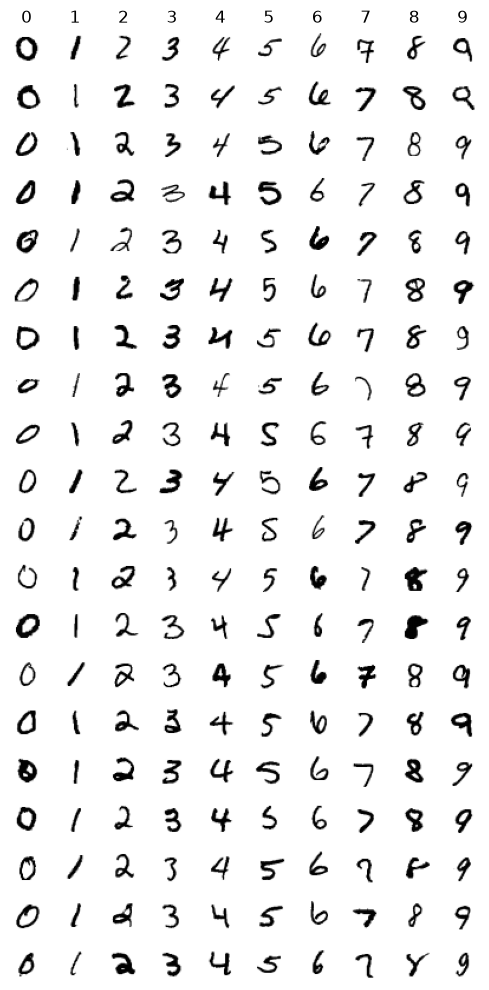

In [2]:
from mnist_datamodule import MNISTDataModule

data_module = MNISTDataModule()

data_module.print_partition_summary()
data_module.plot_samples(n_samples_per_class=20)

## The model

A direct port of the Keras `Sequential` MLP: `784 → 256 → 128 → 10`,
ReLU between, softmax on the output. It was fitted by `train.py`, so
here we just load the checkpoint.

In [3]:
import torch
from mlp import MLP
from train import CHECKPOINT
from mlp_modelmodule import MLPModelModule

model = MLP()
model.load_state_dict(torch.load(CHECKPOINT))
model.eval()

model_module = MLPModelModule(
    selected_layers='dense_1',
    use_onehot_encoder=False,
    model=model,
)

## How good is the model?

This matters for what follows: a cage can only be demonstrated on a
model that actually makes mistakes.

In [4]:
images_val, labels_val = data_module.data_val
predictions_val = model_module._get_predictions(images_val)

incorrect_val = (predictions_val != labels_val).astype(int)

print(f'validation samples : {len(images_val)}')
print(f'accuracy           : {(predictions_val == labels_val).mean():.2%}')
print(f'misclassified      : {incorrect_val.sum()}')

validation samples : 6000
accuracy           : 83.92%
misclassified      : 965


## Maximum Softmax Probability

MSP is the simplest safety cage: it treats the largest class
probability as a confidence score and flags anything below a
threshold. It needs no fitting, which is why `train_cage()` does
nothing here.

Hendrycks & Gimpel (2016), https://arxiv.org/abs/1610.02136

In [5]:
from safetycage.methods.msp import MSP
from safetycage.methods.doctor import DOCTOR

# msp = MSP(model_module=model_module, data_module=data_module)
msp = DOCTOR(model_module=model_module, data_module=data_module, method="max")
msp.train_cage()

statistics_val = msp.predict(images_val, labels_val)


The gap between those two numbers is the entire premise of the
method. If it were absent, MSP would have nothing to work with.

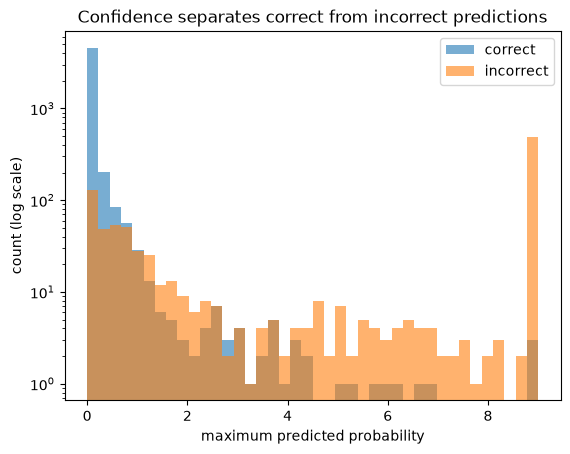

In [6]:
import matplotlib.pyplot as plt

plt.hist(statistics_val[incorrect_val == 0], bins=40, alpha=0.6, label='correct')
plt.hist(statistics_val[incorrect_val == 1], bins=40, alpha=0.6, label='incorrect')
plt.yscale('log')
plt.xlabel('maximum predicted probability')
plt.ylabel('count (log scale)')
plt.title('Confidence separates correct from incorrect predictions')
plt.legend()
plt.show()

## Choosing a threshold

`find_best_threshold` sweeps candidate thresholds and keeps the one
maximising the metric you pass. We use MCC, which reflects both precision and recall - and misclassifications are very much the minority
here.

Note this is the *method* on the cage object.
It takes no `leq` argument; it knows from `msp.leq` that low scores
mean 'flag this'.

In [13]:
from safetycage.utils.metrics import precision, recall, MCC, accuracy, f1_score
metric_fn = MCC

result_val = msp.find_best_threshold(
    y_true=incorrect_val,
    y_probs=statistics_val,
    metric_fn=metric_fn,
)

print(f"optimal threshold : {result_val['threshold_opt']:.4f}")
print(f"{metric_fn.__name__} at threshold  : {float(result_val['metric_max']):.4f}")

optimal threshold : 0.6757
MCC at threshold  : 0.7551


## Applying it to held-out data

The threshold was chosen on validation data. Applying it to the test
split is the only honest estimate of how it will behave in use.

In [14]:
x_test, y_test = data_module.data_test

statistics_test = msp.predict(x_test, y_test)
incorrect_test = (model_module._get_predictions(x_test) != y_test).astype(int)
result_test = msp.find_best_threshold(
    y_true=incorrect_test,
    y_probs=statistics_test,
    metric_fn=metric_fn
)

flagged_test = msp.flag(statistics_test, result_test['threshold_opt'])

caught = int((flagged_test & (incorrect_test == 1)).sum())
total_errors = int(incorrect_test.sum())

print(f'test samples           : {len(x_test)}')
print(f'actually misclassified : {total_errors}')
print(f'flagged by the cage    : {int(flagged_test.sum())}')
print(f'errors caught          : {caught} of {total_errors} ({caught / total_errors:.0%})')


test samples           : 10000
actually misclassified : 1601
flagged by the cage    : 1576
errors caught          : 1261 of 1601 (79%)


Read that block carefully: the cage flags more samples than there are
errors. That is the trade-off, not a defect. Catching most mistakes
means sending some correct predictions for review too, and where you
set the threshold decides which of those two costs you would rather
pay. MCC picked this point; a different metric would pick another.

In [15]:
x_train, y_train = data_module.data_train

statistics_train = msp.predict(x_train, y_train)
incorrect_train = (model_module._get_predictions(x_train) != y_train).astype(int)

result_train = msp.find_best_threshold(
    y_true=incorrect_train,
    y_probs=statistics_train,
    metric_fn=metric_fn,
)

flagged_train = msp.flag(statistics_train, result_train['threshold_opt'])

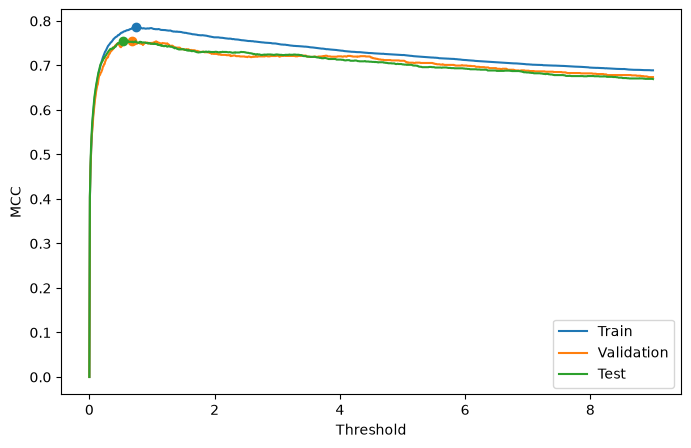

In [16]:
import matplotlib.pyplot as plt
from safetycage.utils.visualise import plot_metric_vs_threshold

fig, ax = plt.subplots(figsize=(8, 5))
plot_metric_vs_threshold(result_train['thresholds'], result_train['metrics'], ax=ax, label='Train')
plot_metric_vs_threshold(result_val['thresholds'], result_val['metrics'], ax=ax, label='Validation')
plot_metric_vs_threshold(result_test['thresholds'], result_test['metrics'], ax=ax, label='Test')
plt.xlabel('Threshold')
plt.ylabel(metric_fn.__name__)
ax.legend()
plt.show()

In [17]:
auroc = msp.auroc(y_true=incorrect_test, y_pred=statistics_test)
roc = msp.roc_curve(y_true=incorrect_test, y_pred=statistics_test)

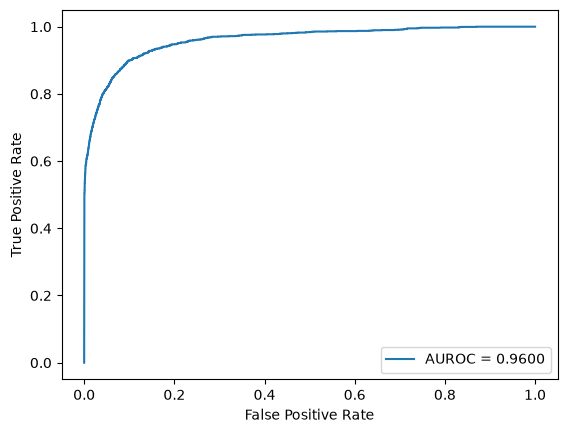

In [18]:
plt.plot(roc['fpr'], roc['tpr'], label=f'AUROC = {auroc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()